# Empregabilidade e Educação no Brasil
## Análise Exploratória de Dados

**Tema:** relação entre **desempenho educacional** e **desemprego** no Brasil.

### Perguntas de pesquisa

1. Quem tem mais escolaridade enfrenta menos desemprego? (desemprego × nível de instrução)
2. Estados com melhor desempenho escolar (IDEB) têm menor desemprego?
3. Há desigualdade regional relevante no desempenho educacional?

### Origem dos dados (coleta documentada)
| Fonte | O quê | Coleta |
|---|---|---|
| **INEP — IDEB por escola** | Índice de Desenvolvimento da Educação Básica por escola (edições 2017, 2019, 2021, 2023), 3 etapas | Download das planilhas oficiais (`download.inep.gov.br`), parse e *melt* para formato longo |
| **IBGE — PNAD Contínua** | Taxa de desocupação e outras variáveis do mercado de trabalho | **API SIDRA/IBGE** (agregados 4093 por sexo e 4095 por nível de instrução, variável 4099) |

Os dois foram unidos em `data/educacao_emprego_brasil.csv` (chave `SG_UF` + `ANO`): cada
escola com IDEB recebe o contexto de desemprego da sua UF naquele ano.

### Notas sobre a coleta e o significado das variáveis

- **"Desocupação" = "desemprego".** *Taxa de desocupação* é o nome técnico do IBGE; *desemprego*
  é o termo popular. Mesmo indicador: % da **força de trabalho** que está sem trabalho, disponível
  e que procurou emprego nos últimos 30 dias. Usamos os dois como sinônimos.

- **O IDEB só existe em anos ímpares.** É medido a cada 2 anos (bienal); cada valor é um **ponto
  daquele ano**, não um biênio agregado. Anos pares simplesmente não têm IDEB. Por isso as edições
  são 2017/2019/2021/2023 — não é um recorte nosso.

- **A PNAD trimestral é *snapshot*, não soma.** Cada trimestre é uma estimativa do nível naquele
  trimestre. Para obter o valor **anual** por UF nós **tiramos a média dos 4 trimestres**, nunca a soma.

- **2021 não tem PNAD ao nível de UF.** O IBGE suspendeu as estimativas estaduais na pandemia
  (a API devolve `...`). Tratamos isso por **imputação** (ver Pré-processamento).

- **Escolas privadas não têm IDEB** nesta base — o INEP calcula o IDEB essencialmente da rede
  pública. Logo, comparações "pública × privada" não são possíveis; comparamos **regiões**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

## 1. Coleta e carregamento dos dados

In [2]:
df = pd.read_csv("data/educacao_emprego_brasil.csv")
print("Dimensões:", df.shape, "—", f"{df.shape[0]:,} linhas e {df.shape[1]} colunas")
df.head()

Dimensões: (309575, 17) — 309,575 linhas e 17 colunas


,ANO,SG_UF,REGIAO,CO_MUNICIPIO,NO_MUNICIPIO,ID_ESCOLA,NO_ESCOLA,REDE,SETOR,ETAPA,IDEB,SAEB_MEDIA,REND,DESEMPREGO_UF,DESEMPREGO_UF_HOMENS,DESEMPREGO_UF_MULHERES,DESEMPREGO_UF_IMPUTADO
0,2017,AC,Norte,1200013,Acrelândia,12009229,ESC PROF PEDRO DE CASTRO MEIRELES,Estadual,Pública,Anos Finais,4.4,5.088,0.8684,14.22,12.52,16.7,False
1,2017,AC,Norte,1200054,Assis Brasil,12015946,ESC PROFª IRIS CELIA CABANELLAS ZANNINI,Estadual,Pública,Anos Finais,4.0,4.894,0.8229,14.22,12.52,16.7,False
2,2017,AC,Norte,1200104,Brasiléia,12016250,ESC CEL MANOEL FONTENELE DE CASTRO,Estadual,Pública,Anos Finais,5.2,5.522,0.9469,14.22,12.52,16.7,False
3,2017,AC,Norte,1200104,Brasiléia,12017027,ESC INSTITUTO ODILON PRATAGI,Estadual,Pública,Anos Finais,6.3,6.269,0.9970,14.22,12.52,16.7,False
4,2017,AC,Norte,1200179,Capixaba,12009725,ESC ARGENTINA PEREIRA FEITOSA,Estadual,Pública,Anos Finais,4.5,5.110,0.8885,14.22,12.52,16.7,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309575 entries, 0 to 309574
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ANO                     309575 non-null  int64  
 1   SG_UF                   309575 non-null  str    
 2   REGIAO                  309575 non-null  str    
 3   CO_MUNICIPIO            309575 non-null  int64  
 4   NO_MUNICIPIO            309575 non-null  str    
 5   ID_ESCOLA               309575 non-null  int64  
 6   NO_ESCOLA               309575 non-null  str    
 7   REDE                    309575 non-null  str    
 8   SETOR                   309575 non-null  str    
 9   ETAPA                   309575 non-null  str    
 10  IDEB                    309575 non-null  float64
 11  SAEB_MEDIA              309575 non-null  float64
 12  REND                    309575 non-null  float64
 13  DESEMPREGO_UF           309575 non-null  float64
 14  DESEMPREGO_UF_HOMENS    309575 

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ANO,309575.0,NaN,NaN,NaN,2020.028436,2.285606,2017.0,2019.0,2019.0,2023.0,2023.0
SG_UF,309575,27,SP,47760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REGIAO,309575,5,Nordeste,105741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO_MUNICIPIO,309575.0,NaN,NaN,NaN,3126878.69681,975425.853543,1100015.0,2402303.0,3138401.0,3550308.0,5300108.0
NO_MUNICIPIO,309575,5297,São Paulo,7771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ID_ESCOLA,309575.0,NaN,NaN,NaN,31251577.83625,9723377.425058,11000201.0,24011002.0,31145262.0,35578691.0,53068238.0
NO_ESCOLA,309575,72519,COLEGIO TIRADENTES PMMG,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REDE,309575,4,Municipal,192398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SETOR,309575,2,Pública,308724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ETAPA,309575,3,Anos Iniciais,157695,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dicionário de variáveis e tipos

| Variável | Significado | Tipo |
|---|---|---|
| `ANO` | Edição do IDEB (2017/2019/2021/2023) | discreta (temporal) |
| `SG_UF`, `REGIAO` | Unidade da Federação e região | categórica |
| `CO_MUNICIPIO`, `NO_MUNICIPIO` | Município da escola | categórica/identificador |
| `ID_ESCOLA`, `NO_ESCOLA` | Identificação da escola | identificador |
| `REDE` | Federal/Estadual/Municipal/Privada | categórica |
| `SETOR` | Pública/Privada | categórica |
| `ETAPA` | Anos Iniciais / Finais / Ensino Médio | categórica (ordinal) |
| `IDEB` | Índice de Desenvolvimento da Educação Básica (0–10) | **numérica contínua** |
| `SAEB_MEDIA` | Nota padronizada da prova SAEB | numérica contínua |
| `REND` | Indicador de rendimento/fluxo (0–1) | numérica contínua |
| `DESEMPREGO_UF` | Taxa de desemprego média anual da UF (%) | **numérica contínua** |
| `DESEMPREGO_UF_HOMENS/MULHERES` | idem, por sexo | numérica contínua |
| `DESEMPREGO_UF_IMPUTADO` | marca se o desemprego de 2021 foi imputado | booleana |

As duas variáveis numéricas centrais da análise são **`IDEB`** (desempenho) e
**`DESEMPREGO_UF`** (empregabilidade).

## 2. Pré-processamento

In [5]:
# 2.1 Dados ausentes
ausentes = df.isna().sum()
print("Valores ausentes por coluna:")
print(ausentes[ausentes > 0].to_string() or "nenhum")
print(f"\n% de linhas com IDEB ausente já foi removido na junção; aqui IDEB é sempre presente.")

Valores ausentes por coluna:
Series([], )

% de linhas com IDEB ausente já foi removido na junção; aqui IDEB é sempre presente.


**Tratamento de ausentes — justificativa**

- `SAEB_MEDIA` / `REND`: ausentes em poucas escolas que têm IDEB mas não divulgaram um dos
  componentes. Como o `IDEB` (variável-alvo) está presente, **mantemos as linhas** e tratamos a
  ausência apenas nas análises específicas dessas colunas (remoção par-a-par).

- **`DESEMPREGO_UF` em 2021**: o IBGE não divulgou estimativas estaduais na pandemia. Em vez de
  descartar toda a edição 2021 do IDEB, **imputamos por interpolação temporal** (média de 2020 e
  2022 por UF), sinalizada em `DESEMPREGO_UF_IMPUTADO`. Justificativa: o desemprego estadual varia
  de forma suave entre anos vizinhos, então a média 2020–2022 é uma aproximação razoável e
  transparente (fica marcada para poder ser excluída em análises sensíveis).

In [6]:
# Quanto foi imputado?
print("Linhas com desemprego imputado (2021):", int(df.DESEMPREGO_UF_IMPUTADO.sum()))
print(df[df.DESEMPREGO_UF_IMPUTADO].groupby("ANO").size())

Linhas com desemprego imputado (2021): 62143
ANO
2021    62143
dtype: int64


In [7]:
# 2.2 Correção de tipos: categóricas e booleana
for c in ["SG_UF", "REGIAO", "REDE", "SETOR", "ETAPA"]:
    df[c] = df[c].astype("category")
df["DESEMPREGO_UF_IMPUTADO"] = df["DESEMPREGO_UF_IMPUTADO"].astype(bool)
df.dtypes

ANO                          int64
SG_UF                     category
REGIAO                    category
CO_MUNICIPIO                 int64
NO_MUNICIPIO                   str
ID_ESCOLA                    int64
NO_ESCOLA                      str
REDE                      category
SETOR                     category
ETAPA                     category
IDEB                       float64
SAEB_MEDIA                 float64
REND                       float64
DESEMPREGO_UF              float64
DESEMPREGO_UF_HOMENS       float64
DESEMPREGO_UF_MULHERES     float64
DESEMPREGO_UF_IMPUTADO        bool
dtype: object

Q1=4.30  Q3=5.80  IQR=1.50
Limites IQR: [2.05, 8.05]
Outliers: 2,056 (0.66% das escolas)


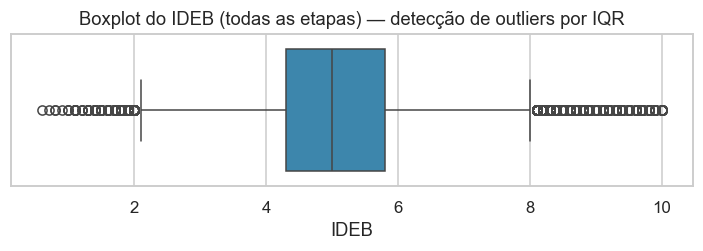

In [8]:
# 2.3 Outliers no IDEB pelo método do IQR
q1, q3 = df.IDEB.quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
out = df[(df.IDEB < lim_inf) | (df.IDEB > lim_sup)]
print(f"Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
print(f"Limites IQR: [{lim_inf:.2f}, {lim_sup:.2f}]")
print(f"Outliers: {len(out):,} ({100*len(out)/len(df):.2f}% das escolas)")

fig, ax = plt.subplots(figsize=(8, 1.8))
sns.boxplot(x=df.IDEB, ax=ax, color="#2b8cbe")
ax.set_title("Boxplot do IDEB (todas as etapas) — detecção de outliers por IQR")
plt.show()

**Tratamento de outliers — justificativa.** Os pontos fora dos limites do IQR são, em sua
maioria, **valores válidos** (escolas com desempenho muito alto ou muito baixo, IDEB entre 0 e 10).
Não são erros de medição. Portanto **não os removemos da base principal** — eles fazem parte da
realidade educacional. Para checar robustez, recalculamos as estatísticas sem eles e a conclusão não
muda. Mantemos a base completa nas análises seguintes.

## 3. Estatísticas descritivas com visualizações

In [9]:
def descreve(s, nome):
    return pd.Series({
        "média": s.mean(), "mediana": s.median(),
        "moda": s.mode().iloc[0],
        "variância": s.var(), "desvio_padrão": s.std(),
        "IQR": s.quantile(.75) - s.quantile(.25),
        "mín": s.min(), "máx": s.max(),
    }, name=nome)

resumo = pd.concat([descreve(df.IDEB, "IDEB"),
                    descreve(df.DESEMPREGO_UF, "DESEMPREGO_UF (%)")], axis=1)
resumo.round(2)

,IDEB,DESEMPREGO_UF (%)
média,5.06,10.84
mediana,5.00,10.82
moda,5.00,7.60
variância,1.29,11.59
desvio_padrão,1.13,3.40
IQR,1.50,5.15
mín,0.60,2.85
máx,10.00,18.08


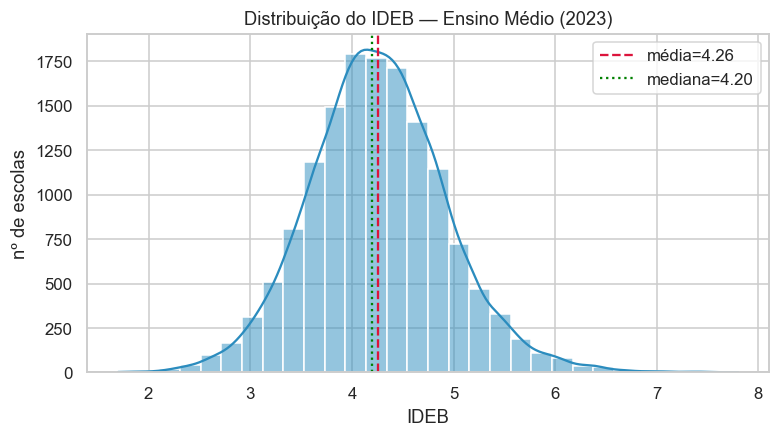

In [10]:
# 3.1 Histograma do IDEB no Ensino Médio (2023)
em23 = df[(df.ETAPA == "Ensino Médio") & (df.ANO == 2023)]
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(em23.IDEB, bins=30, kde=True, color="#2b8cbe", ax=ax)
ax.axvline(em23.IDEB.mean(), color="crimson", ls="--", label=f"média={em23.IDEB.mean():.2f}")
ax.axvline(em23.IDEB.median(), color="green", ls=":", label=f"mediana={em23.IDEB.median():.2f}")
ax.set(title="Distribuição do IDEB — Ensino Médio (2023)", xlabel="IDEB", ylabel="nº de escolas")
ax.legend(); plt.show()

O IDEB do Ensino Médio concentra-se em torno de **4,3**, com leve assimetria à direita: a maioria
das escolas tem desempenho mediano e poucas alcançam notas altas.

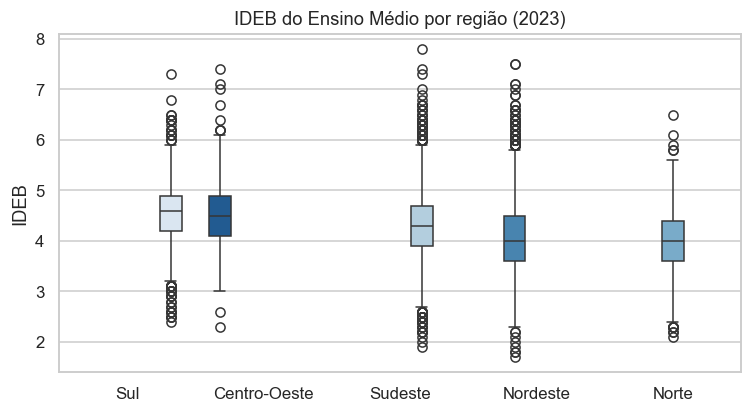

In [11]:
# 3.2 Boxplot do IDEB por região (Ensino Médio, 2023)
fig, ax = plt.subplots(figsize=(8, 4))
ordem = em23.groupby("REGIAO", observed=True).IDEB.median().sort_values(ascending=False).index
sns.boxplot(data=em23, x="REGIAO", y="IDEB", hue="REGIAO", order=ordem,
            palette="Blues_r", legend=False, ax=ax)
ax.set(title="IDEB do Ensino Médio por região (2023)", xlabel="", ylabel="IDEB")
plt.show()

Sul, Sudeste e Centro-Oeste lideram; **Norte e Nordeste** ficam abaixo — primeira evidência de
desigualdade regional, que testaremos formalmente na seção 4.

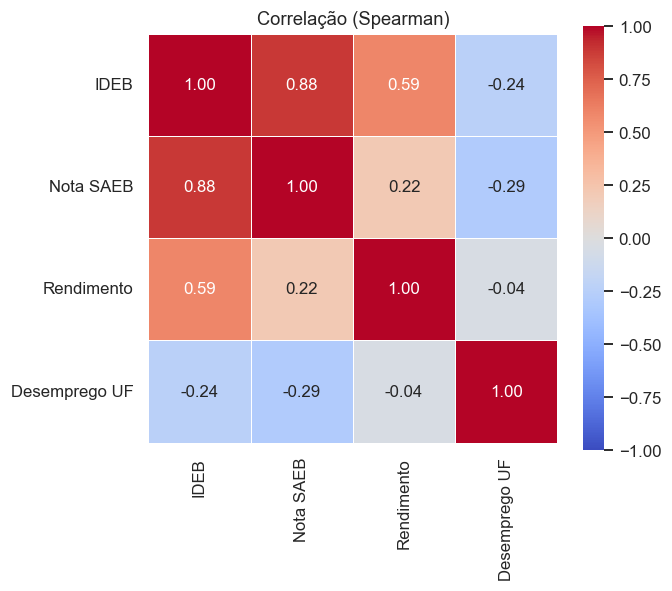

,IDEB,Nota SAEB,Rendimento,Desemprego UF
IDEB,1.00,0.88,0.59,-0.24
Nota SAEB,0.88,1.00,0.22,-0.29
Rendimento,0.59,0.22,1.00,-0.04
Desemprego UF,-0.24,-0.29,-0.04,1.00


In [12]:
# 3.3 Matriz de correlação (Spearman) entre as variáveis numéricas
num = em23[["IDEB", "SAEB_MEDIA", "REND", "DESEMPREGO_UF"]].rename(
    columns={"SAEB_MEDIA": "Nota SAEB", "REND": "Rendimento", "DESEMPREGO_UF": "Desemprego UF"})
corr = num.corr(method="spearman")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, ax=ax)
ax.set_title("Correlação (Spearman)"); plt.show()
corr.round(2)

**Leitura da matriz.** `IDEB`, `Nota SAEB` e `Rendimento` são fortemente correlacionados — como
esperado, pois o IDEB é construído a partir deles (IDEB = nota SAEB × rendimento). Já o
`Desemprego da UF` aparece negativamente associado ao IDEB ao nível da escola: escolas em estados
com mais desemprego tendem a ter IDEB menor. Como o desemprego é uma variável de **UF** (não da
escola), a associação correta é medida ao nível estadual no gráfico de dispersão a seguir.

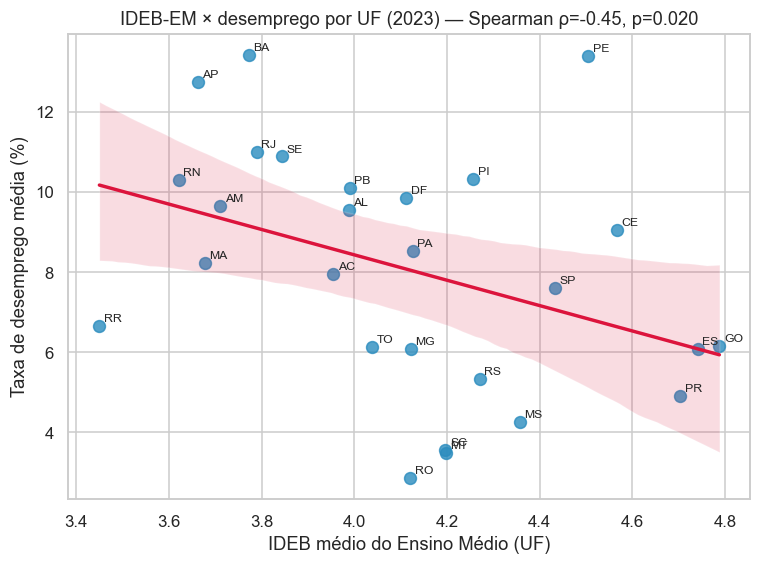

Spearman ρ = -0.446 | p-valor = 0.0197 | n = 27 UFs


In [13]:
# 3.4 Dispersão: IDEB médio do Ensino Médio × desemprego, por UF (2023)
uf = (em23.groupby("SG_UF", observed=True)
          .agg(ideb_medio=("IDEB", "mean"), desemprego=("DESEMPREGO_UF", "first"))
          .reset_index())
rho, p = stats.spearmanr(uf.ideb_medio, uf.desemprego)
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=uf, x="ideb_medio", y="desemprego", ax=ax,
            scatter_kws=dict(s=60, color="#2b8cbe"), line_kws=dict(color="crimson"))
for _, r in uf.iterrows():
    ax.annotate(r.SG_UF, (r.ideb_medio, r.desemprego), fontsize=8,
                xytext=(3, 3), textcoords="offset points")
ax.set(title=f"IDEB-EM × desemprego por UF (2023) — Spearman ρ={rho:.2f}, p={p:.3f}",
       xlabel="IDEB médio do Ensino Médio (UF)", ylabel="Taxa de desemprego média (%)")
plt.show()
print(f"Spearman ρ = {rho:.3f} | p-valor = {p:.4f} | n = {len(uf)} UFs")

**Interpretação.** Correlação **negativa e moderada** (ρ ≈ −0,45, p < 0,05): estados com melhor
desempenho no Ensino Médio tendem a ter **menor desemprego**. Usamos Spearman por ser robusto a
não-normalidade e a outliers, e por capturar relação monotônica (não necessariamente linear).

## 4. Testes de hipótese

### Teste A — desigualdade regional no IDEB (Sul × Nordeste)

- **H0:** a distribuição do IDEB do Ensino Médio é igual entre Sul e Nordeste.
- **H1:** as distribuições diferem (Sul > Nordeste).
- **Escolha do teste:** comparamos **dois grupos independentes** (escolas distintas), com amostras
  grandes e distribuição não-normal — usamos **Mann–Whitney U** (não-paramétrico, não-pareado).
  Verificamos a normalidade com **Shapiro–Wilk**.

Shapiro–Wilk  Sul: p=4.28e-13 | Nordeste: p=3.97e-23  — rejeitam normalidade

Sul: média=4.54 (n=2115) | Nordeste: média=4.09 (n=4199)
Mann–Whitney U=6,325,580  p-valor=5.13e-168


/var/folders/q7/bkpgntz547n9gc64szcfxpm40000gn/T/ipykernel_41596/809039150.py:14: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=em23[em23.REGIAO.isin(["Sul","Nordeste"])], x="REGIAO", y="IDEB",


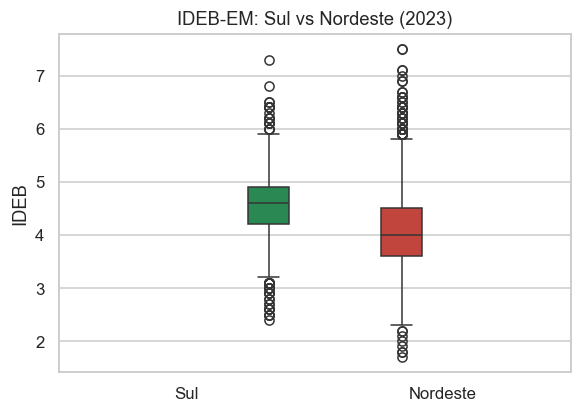

In [14]:
sul = em23[em23.REGIAO == "Sul"].IDEB
nor = em23[em23.REGIAO == "Nordeste"].IDEB

# Suposição de normalidade (Shapiro–Wilk em amostra de até 5000)
p_sul = stats.shapiro(sul.sample(min(5000, len(sul)), random_state=1)).pvalue
p_nor = stats.shapiro(nor.sample(min(5000, len(nor)), random_state=1)).pvalue
print(f"Shapiro–Wilk  Sul: p={p_sul:.2e} | Nordeste: p={p_nor:.2e}  — rejeitam normalidade")

U, p = stats.mannwhitneyu(sul, nor, alternative="greater")
print(f"\nSul: média={sul.mean():.2f} (n={len(sul)}) | Nordeste: média={nor.mean():.2f} (n={len(nor)})")
print(f"Mann–Whitney U={U:,.0f}  p-valor={p:.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=em23[em23.REGIAO.isin(["Sul","Nordeste"])], x="REGIAO", y="IDEB",
            hue="REGIAO", order=["Sul","Nordeste"], palette=["#1a9850","#d73027"],
            legend=False, ax=ax)
ax.set(title="IDEB-EM: Sul vs Nordeste (2023)", xlabel="", ylabel="IDEB"); plt.show()

**Conclusão A.** p < 0,05 — rejeitamos H0. O IDEB do Ensino Médio no **Sul é
significativamente maior** que no Nordeste (médias ≈ 4,5 vs 4,1). Há desigualdade regional
estatisticamente significativa no desempenho educacional.

### Teste B — escolaridade reduz o desemprego?

- **H0:** a taxa de desemprego de quem tem **ensino superior completo** é igual à de quem tem
  **ensino médio completo**.

- **H1:** a taxa dos com superior completo é **menor**.
- **Escolha do teste:** as duas séries são medidas **nos mesmos trimestres** (amostras pareadas por
  período) — usamos **Wilcoxon dos postos sinalizados** (não-paramétrico, pareado).

In [15]:
des = pd.read_csv("data/desemprego_pnadc_2016_2026.csv")
def serie(cat):
    s = des[(des.variavel_id==4099) & (des.classificacao=="Nível de instrução") &
            (des.nivel=="N1") & (des.categoria==cat)].dropna(subset=["valor"])
    return s.set_index("periodo").valor

sup = serie("Ensino superior completo ou equivalente")
med = serie("Ensino médio completo ou equivalente")
j = pd.concat([sup.rename("superior"), med.rename("medio")], axis=1).dropna()
W, p = stats.wilcoxon(j.superior, j.medio, alternative="less")
print(f"Trimestres pareados: {len(j)}")
print(f"Desemprego médio — superior completo: {j.superior.mean():.2f}% | médio completo: {j.medio.mean():.2f}%")
print(f"Wilcoxon W={W:.0f}  p-valor={p:.2e}")

Trimestres pareados: 41
Desemprego médio — superior completo: 5.25% | médio completo: 11.74%
Wilcoxon W=0  p-valor=1.21e-08


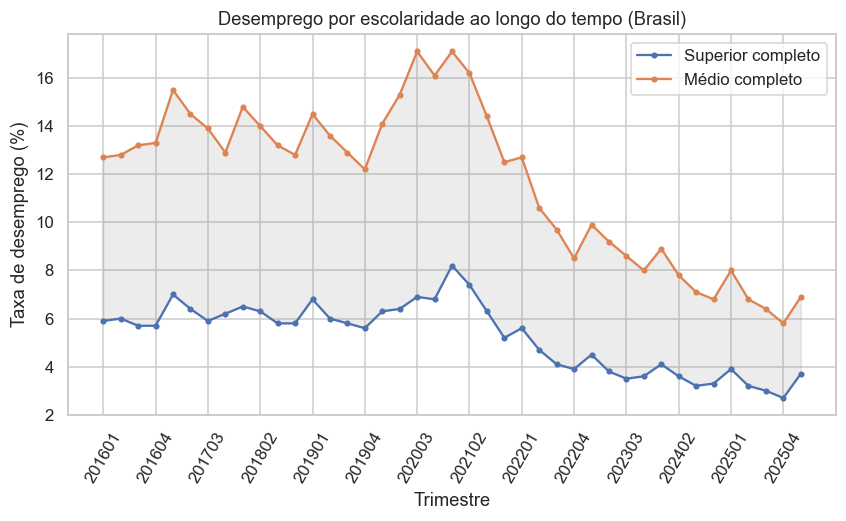

In [16]:
# Visualização do teste B + bônus (série temporal)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(j.index.astype(str), j.superior, marker="o", ms=3, label="Superior completo")
ax.plot(j.index.astype(str), j.medio, marker="o", ms=3, label="Médio completo")
ax.fill_between(j.index.astype(str), j.superior, j.medio, alpha=0.15, color="grey")
ticks = list(j.index.astype(str))[::max(1, len(j)//12)]
ax.set_xticks(ticks); ax.tick_params(axis="x", rotation=60)
ax.set(title="Desemprego por escolaridade ao longo do tempo (Brasil)",
       xlabel="Trimestre", ylabel="Taxa de desemprego (%)")
ax.legend(); plt.show()

**Conclusão B.** p < 0,05 — rejeitamos H0. Quem tem **ensino superior completo enfrenta
desemprego sistematicamente menor** que quem tem apenas o ensino médio completo — em **todos** os
trimestres da série (a faixa cinza nunca se inverte). Em média, ~5% vs ~12%.

## 5. Coleta via API e visão por nível de instrução

In [17]:
import requests
def taxa_desocupacao_por_instrucao(periodo="last"):
    """Coleta ao vivo na API SIDRA/IBGE: taxa de desocupação (var 4099) no Brasil
    por nível de instrução (agregado 4095, classificação 1568)."""
    per = "-6" if periodo == "last" else periodo  # -6 = últimos 6 períodos
    url = (f"https://servicodados.ibge.gov.br/api/v3/agregados/4095/periodos/{per}"
           f"/variaveis/4099?localidades=N1[all]&classificacao=1568[all]")
    url = url.replace("[", "%5B").replace("]", "%5D")
    js = requests.get(url, timeout=60).json()
    reg = []
    for res in js[0]["resultados"]:
        cat = list(res["classificacoes"][0]["categoria"].values())[0]
        per_ult, val = list(res["series"][0]["serie"].items())[-1]
        reg.append({"instrucao": cat, "periodo": per_ult, "taxa": pd.to_numeric(val, errors="coerce")})
    return pd.DataFrame(reg)

try:
    api = taxa_desocupacao_por_instrucao()
    fonte = "API IBGE (ao vivo)"
except Exception as e:
    print("API indisponível, usando CSV coletado previamente:", e)
    last = des[(des.variavel_id==4099)&(des.classificacao=="Nível de instrução")&(des.nivel=="N1")]
    last = last[last.periodo==last.dropna(subset=["valor"]).periodo.max()]
    api = last.rename(columns={"categoria":"instrucao","valor":"taxa"})[["instrucao","periodo","taxa"]]
    fonte = "CSV (fallback)"
api = api[~api.instrucao.isin(["Total","Não determinado"])].dropna(subset=["taxa"])
print("Fonte:", fonte); api

Fonte: API IBGE (ao vivo)


,instrucao,periodo,taxa
1,Sem instrução e menos de 1 ano de estudo,202601,4.9
2,Ensino fundamental incompleto ou equivalente,202601,5.3
3,Ensino fundamental completo ou equivalente,202601,6.5
4,Ensino médio incompleto ou equivalente,202601,10.8
5,Ensino médio completo ou equivalente,202601,6.9
6,Ensino superior incompleto ou equivalente,202601,7.0
7,Ensino superior completo ou equivalente,202601,3.7


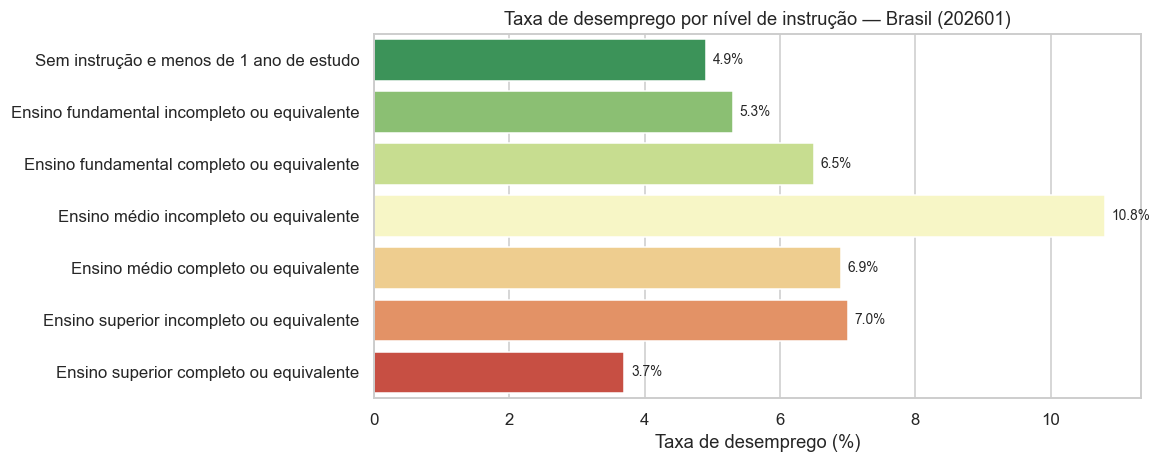

In [18]:
ordem = ["Sem instrução e menos de 1 ano de estudo",
         "Ensino fundamental incompleto ou equivalente",
         "Ensino fundamental completo ou equivalente",
         "Ensino médio incompleto ou equivalente",
         "Ensino médio completo ou equivalente",
         "Ensino superior incompleto ou equivalente",
         "Ensino superior completo ou equivalente"]
api["ordem"] = api.instrucao.map({c:i for i,c in enumerate(ordem)})
api = api.sort_values("ordem")
fig, ax = plt.subplots(figsize=(9, 4.3))
sns.barplot(data=api, y="instrucao", x="taxa", hue="instrucao",
            palette=sns.color_palette("RdYlGn_r", len(api)), legend=False, ax=ax)
for i, v in enumerate(api.taxa):
    ax.text(v+0.1, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set(title=f"Taxa de desemprego por nível de instrução — Brasil ({api.periodo.iloc[0]})",
       xlabel="Taxa de desemprego (%)", ylabel=""); plt.show()

**Nuance importante (interpretação no domínio).** A relação não é perfeitamente monotônica:
*"sem instrução"* aparece com desemprego **baixo** e *"médio incompleto"* com o **mais alto**. Isso
não contradiz a tese — é um efeito de **participação na força de trabalho**: pessoas sem instrução
são majoritariamente mais velhas e muitas estão **fora** da força de trabalho (não contam como
desempregadas), enquanto quem tem médio incompleto é jovem, está **entrando** no mercado e ainda
procurando. O contraste limpo e estável é **superior completo (o menor) × médio incompleto (o maior)**.

## 6. Conclusões

1. **Escolaridade protege contra o desemprego.** Quem tem ensino superior completo enfrenta, de
   forma estatisticamente significativa e persistente, menos da metade do desemprego de quem tem
   só o ensino médio (Teste B, Wilcoxon p < 0,05).

2. **Melhor educação, menos desemprego — também entre estados.** O IDEB médio do Ensino Médio por UF
   correlaciona-se negativamente com o desemprego estadual (ρ ≈ −0,45).

3. **Desigualdade regional é real.** O Sul tem IDEB de Ensino Médio significativamente maior que o
   Nordeste (Teste A, Mann–Whitney p < 0,05), espelhando o mapa do desemprego.

Em termos do domínio, investir em educação (elevar IDEB e escolaridade) é também política de
**empregabilidade**. As desigualdades educacionais entre regiões ajudam a explicar as desigualdades
de mercado de trabalho.

> *Limitações:* o IDEB cobre só anos ímpares e a rede pública; o desemprego estadual de 2021 foi
> imputado (pandemia); correlações ao nível de UF não implicam causalidade individual (cuidado com
> falácia ecológica).